In [ ]:
# Install Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load and Inspect Data
# Load the dataset
df = pd.read_csv("C:\\Users\\HP\\OneDrive\\Documents\\MUMBAI UNIVERSITY\\SEM 2\\PRODIGY_DS_02\\train.csv")

# Look at the first few rows
print(df.head())

# Check for missing values (This is the most important part of EDA)
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

In [4]:
# Step 2: Data Cleaning (Handling Missing Values)
# 1. Fill missing Age with the median age (Better than mean for skewed data)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Fill missing Embarked with the most common port (Mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Drop 'Cabin' because it has too many missing values to be useful
df.drop(columns=['Cabin'], inplace=True)

# Confirm everything is clean
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


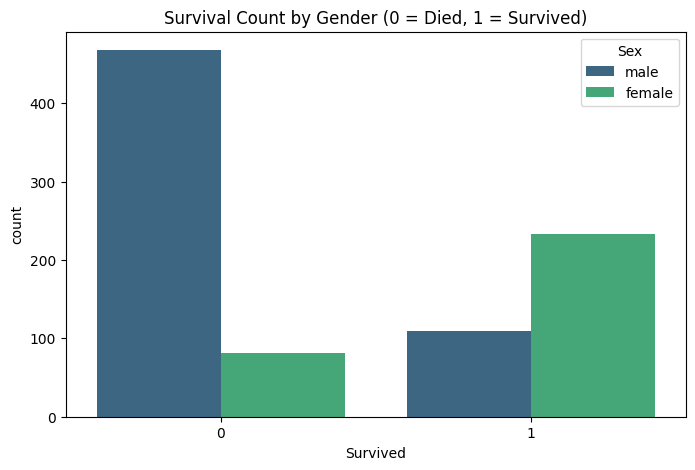

In [5]:
# Step 3: Exploratory Data Analysis (EDA)
# A. Survival by Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=df, palette='viridis')
plt.title('Survival Count by Gender (0 = Died, 1 = Survived)')
plt.show()

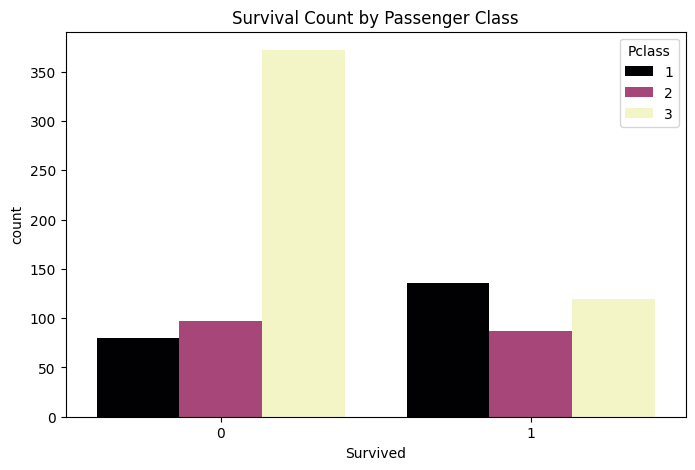

In [6]:
# B. Survival by Passenger Class
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='magma')
plt.title('Survival Count by Passenger Class')
plt.show()

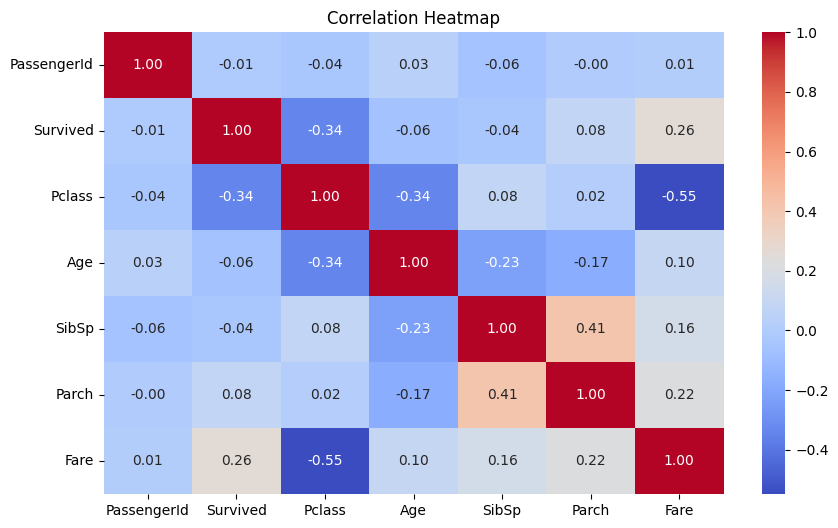

In [ ]:
# Step 4: Understanding Relationships
# A "Heatmap" is a great way to show how different variables (Age, Fare, Class) relate to each other.
plt.figure(figsize=(10, 6))
# Only use numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()